## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Lecture des données

In [2]:
data = pd.read_csv('../data/performances.csv')
data

,perf_id,perf_date,perf_temps,perf_nage,perf_distance,perf_bassin,competition_ville,competition_pays,nageur_id,nageur_sexe,nageur_date_naissance,nageur_pays,nageur_age_mois,mois_saison
0,3,1996-04-04 00:00:00,0.2663,Nage Libre,50,50,DUNKERQUE,FRA,326914,F,1975-11-09,FRA,244,7
1,185,1996-04-04 00:00:00,4.3242,Nage Libre,400,50,DUNKERQUE,FRA,30347,F,1978-01-01,FRA,219,7
2,186,1996-04-04 00:00:00,4.3277,Nage Libre,400,50,DUNKERQUE,FRA,132447,F,1976-03-09,FRA,240,7
3,189,1996-04-04 00:00:00,4.3465,Nage Libre,400,50,DUNKERQUE,FRA,144752,F,1982-03-11,FRA,168,7
4,193,1996-04-04 00:00:00,4.3657,Nage Libre,400,50,DUNKERQUE,FRA,89589,F,1980-03-11,FRA,192,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15196042,5543601,2010-12-05 00:00:00,3.2104,Papillon,200,25,ANTIBES,FRA,1077520,M,1998-10-30,FRA,145,3
15196043,5543608,2010-12-05 00:00:00,2.5808,Papillon,200,25,ANTIBES,FRA,1126041,M,1998-06-19,FRA,149,3
15196044,5543615,2010-12-05 00:00:00,2.5533,Papillon,200,25,ANTIBES,FRA,942995,M,1999-02-17,SEY,141,3
15196045,5543618,2010-12-05 00:00:00,2.5522,Papillon,200,25,ANTIBES,FRA,1035804,M,1999-09-10,FRA,134,3


Nous supprimons les valeurs invalides du jeu de données.

In [3]:
data = data.dropna(how='any',axis=0)
data.describe()

,perf_id,perf_temps,perf_distance,perf_bassin,nageur_id,nageur_age_mois,mois_saison
count,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07,1.519605e+07
mean,1.298771e+07,1.748004e+00,1.398700e+02,3.331302e+01,1.593994e+06,1.938763e+02,5.521579e+00
std,6.423676e+06,2.384063e+00,1.680907e+02,1.177791e+01,9.359901e+05,1.029630e+02,2.786871e+00
min,1.000000e+00,1.085000e-01,2.500000e+01,2.500000e+01,-1.058890e+05,-2.612100e+04,0.000000e+00
25%,8.078232e+06,4.155000e-01,5.000000e+01,2.500000e+01,9.889990e+05,1.460000e+02,3.000000e+00
50%,1.342845e+07,1.142200e+00,1.000000e+02,2.500000e+01,1.480898e+06,1.690000e+02,6.000000e+00
75%,1.846193e+07,2.211300e+00,2.000000e+02,5.000000e+01,2.099575e+06,1.980000e+02,8.000000e+00
max,2.322727e+07,6.140700e+02,3.000000e+03,5.000000e+01,4.404826e+06,1.211000e+03,1.100000e+01


Ici, nous observons certaines anomalies, comme le fait que la variable `nageur_age_mois` ait une valeur minimale inférieure à 0.

In [ ]:
data = data[data['nageur_age_mois'] > 0]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15196044 entries, 0 to 15196046
Data columns (total 14 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   perf_id                int64  
 1   perf_date              object 
 2   perf_temps             float64
 3   perf_nage              object 
 4   perf_distance          int64  
 5   perf_bassin            int64  
 6   competition_ville      object 
 7   competition_pays       object 
 8   nageur_id              int64  
 9   nageur_sexe            object 
 10  nageur_date_naissance  object 
 11  nageur_pays            object 
 12  nageur_age_mois        int64  
 13  mois_saison            int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.7+ GB


## Data Analysis

In [ ]:
data[['nageur_age_mois']].describe()

,nageur_age_mois
count,1.519604e+07
mean,1.938815e+02
std,1.022970e+02
min,8.000000e+00
25%,1.460000e+02
50%,1.690000e+02
75%,1.980000e+02
max,1.211000e+03


L'âge moyen d'un nageur ici est de 193 mois (16 ans). La médiane est de 169 (14 ans), tandis que la valeur maximale est de 1211 mois (100 ans !!) et la valeur minimale semble être une anomalie avec seulement 8 mois. Après quelques recherches, il semble qu'en France il n'est pas possible de nager en club avant 4 ans (48 mois), donc nous filtrons ces cas.

In [6]:
data = data[data['nageur_age_mois'] > 48]
data[['nageur_age_mois']].describe()

,nageur_age_mois
count,1.519604e+07
mean,1.938815e+02
std,1.022970e+02
min,4.900000e+01
25%,1.460000e+02
50%,1.690000e+02
75%,1.980000e+02
max,1.211000e+03


Nous avons maintenant une valeur minimale de 49 mois, ce qui semble légitime.

<Axes: ylabel='Frequency'>

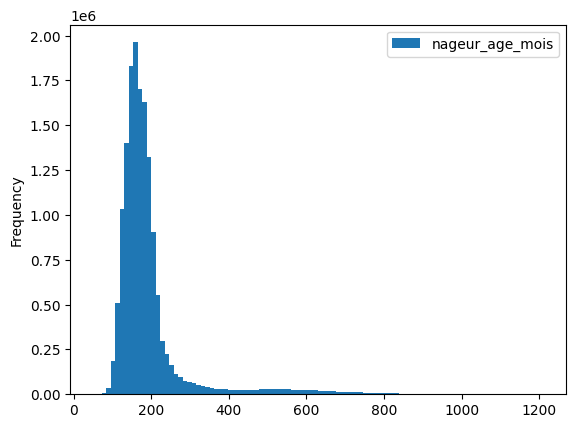

In [7]:
data[['nageur_age_mois']].plot.hist(bins=100)

Nous constatons que la majorité des compétiteurs ont entre 150 et 300 mois (soit entre 12 et 25 ans). Le reste est assez bien réparti entre 400 et 800 mois (33 à 66 ans). La population des compétiteurs en natation est donc surreprésentée par les jeunes.

<Axes: xlabel='perf_distance'>

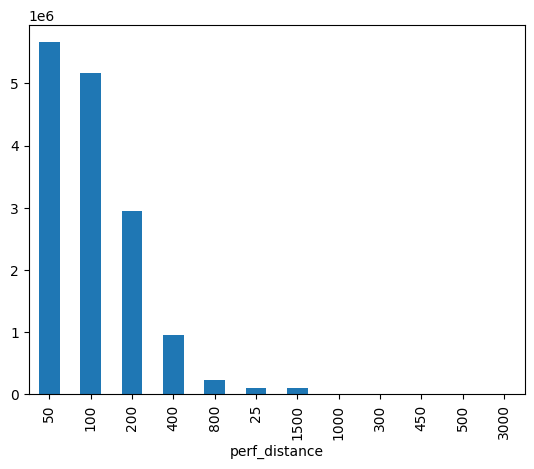

In [15]:
data['perf_distance'].value_counts().plot.bar()

Nous constatons ici que les distances les plus représentées en compétition sont 50, 100 et 200 mètres. Cela reflète la popularité des épreuves de sprint et de demi-fond en natation, qui attirent le plus grand nombre de participants. Les autres distances, bien que présentes, sont moins courantes et concernent souvent des nageurs spécialisés ou des compétitions spécifiques.

<Axes: xlabel='perf_nage'>

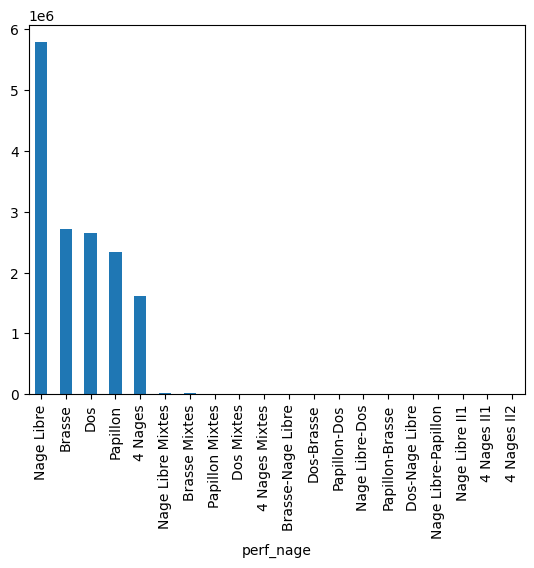

In [14]:
data['perf_nage'].value_counts().plot.bar()

La catégorie Nage libre est de loin la plus représentée en compétition, avec la Brasse, le Dos, le Papillon et les 4 Nages également bien présents. Toutes les autres catégories sont des variantes ou des versions mixtes de ces grandes catégories.

<Axes: xlabel='perf_bassin'>

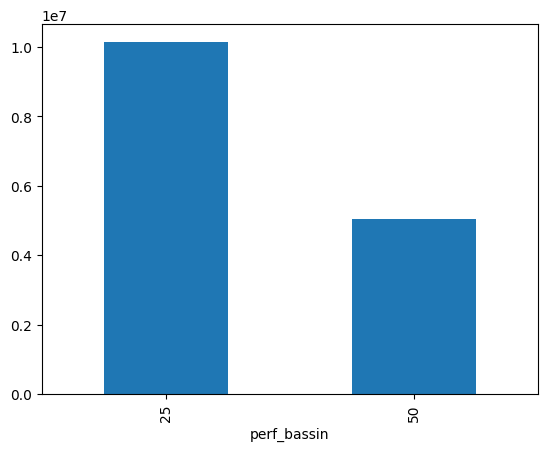

In [16]:
data['perf_bassin'].value_counts().plot.bar()

Nous constatons ici que la majorité des compétitions se déroulent dans des piscines semi-olympiques de 25 mètres, soit environ deux fois plus que dans des piscines olympiques de 50 mètres. Cela s’explique notamment par le fait que les piscines de 25 mètres sont plus répandues en France, facilitant l’organisation de compétitions locales et régionales. Les piscines olympiques, plus rares et coûteuses, sont généralement réservées aux grandes compétitions nationales ou internationales.

<Axes: xlabel='mois_saison'>

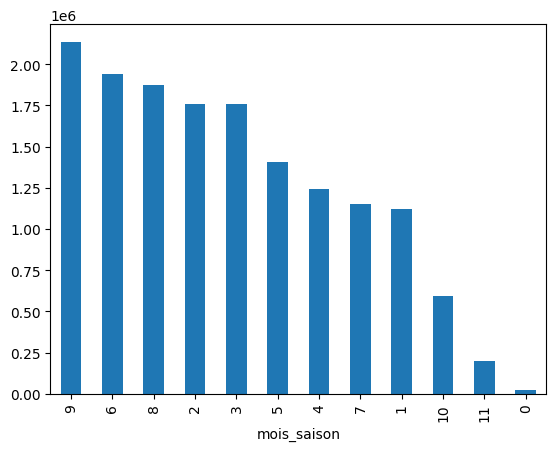

In [17]:
data['mois_saison'].value_counts().plot.bar()

Les compétitions de natation ne sont pas réparties uniformément tout au long de l'année. Elles atteignent un pic à certains mois, probablement en raison des calendriers scolaires, de la météo ou des programmes des compétitions nationales.

<Axes: xlabel='nageur_sexe'>

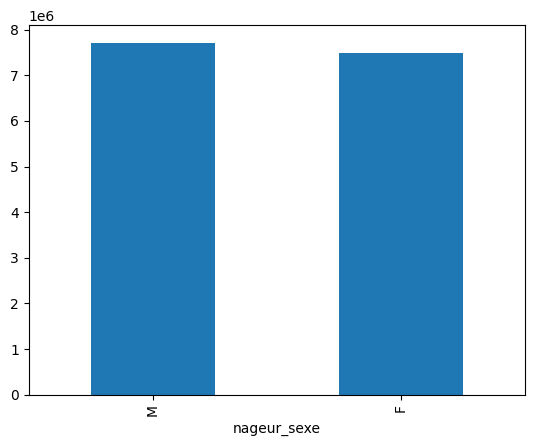

In [18]:
data['nageur_sexe'].value_counts().plot.bar()

Nous constatons ici que la participation aux compétitions de natation est répartie de manière égale entre les hommes et les femmes. Cela reflète une parité dans l'accès et l'intérêt pour la pratique de la natation en compétition, sans déséquilibre notable entre les deux sexes.